# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# [replaced classroom cell] The Colab/zip loader and `!pip install` are not needed here:
# the client pack lives in source_systems/ and dependencies come from requirements.txt.
import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path
import pandas as pd
import requests
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "source_systems").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
BASE = ROOT / "source_systems"                    # read-only client systems
sys.path.insert(0, str(ROOT / "src"))
OUT = ROOT / "Challenges" / "output"             # scratch outputs of the challenge notebooks
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100); pd.set_option("display.width", 170); pd.set_option("display.max_colwidth", 90)
print("BASE:", BASE, "| database exists:", (BASE / "database" / "flasheats.db").exists())

BASE: B:\Trimester-9\FDE\assignment-2\source_systems | database exists: True


In [2]:
# [replaced classroom cell] pack already located by the setup cell above
print("BASE:", BASE)
print("Exists:", BASE.exists())

BASE: B:\Trimester-9\FDE\assignment-2\source_systems
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time |  |  |
| Actual delivery time |  |  |
| Driver assignment |  |  |
| Customer complaint |  |  |
| Restaurant status |  |  |
| Driver movement/events |  |  |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

> ✅ **Answer**

| Information | Likely source | Authoritative? | Why |
|---|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite) | **Yes**: the promise the customer saw | Dispatch's `current_delivery_eta` is a later revision |
| Actual delivery time | `orders.actual_delivery_at` | **Yes**, but 37 delivered orders have none | the driver-app `delivered` event could back-fill them; that needs the owner's sign-off |
| Driver assignment | Dispatch API (`assigned_at`, `reassigned_at`, `driver_id`) | **Yes** for the final driver | `orders.driver_id` keeps the *original* driver after a reassignment |
| Customer complaint | `support_tickets.csv` | yes for *what the customer said* | only contextual for what happened |
| Restaurant status | `restaurant_status.csv` | contextual | covers 31 % of orders, minute precision, mixed spellings |
| Driver movement | `driver_events.json` | yes for movement | no *arrived at restaurant* event |

In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** ______________________________
- **Denominator:** _____________________________
- **Cancelled orders:** include / exclude / other?
- **Missing actual delivery timestamp:** what will you do?
- **Row grain:** what does one row represent?

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
# Starter syntax only — complete the analysis yourself.

# SQL examples:
# SELECT order_id, promised_eta, actual_delivery_at, final_status
# FROM orders
# WHERE ...

query = """
SELECT *
FROM orders
LIMIT 20;
"""

orders_preview = pd.read_sql(query, con)
display(orders_preview)

# Useful pandas syntax:
# df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
# df["delay_min"] = (df["actual"] - df["promised"]).dt.total_seconds() / 60
# df["order_id"].duplicated().sum()
# df.isna().sum()

# TODO: your Challenge 1 analysis

,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear
5,O00006,C0152,R052,D120,Bengaluru,2026-08-26T23:02:00,2026-08-26T23:58:18.214888,2026-08-26T23:31:33.631520,2026-08-27T00:05:36.182189,delivered,6.81,high,clear
6,O00007,C0875,R021,D094,Bengaluru,2026-08-14T11:47:00,2026-08-14T13:14:54,2026-08-14T12:06:06.040105,2026-08-14T13:19:10.066680,delivered,18.00,severe,rain
7,O00008,C0223,R010,D031,Bengaluru,2026-08-27T22:22:00,2026-08-27T23:40:06,2026-08-27T23:11:00.536098,2026-08-28T00:06:57.494136,delivered,18.00,medium,rain
8,O00009,C0685,R053,D078,Bengaluru,2026-08-09T13:16:00,2026-08-09T14:21:32.383307,2026-08-09T13:48:11.662156,2026-08-09T14:22:13.491008,delivered,14.54,low,clear
9,O00010,C0530,R006,D082,Bengaluru,2026-08-22T13:27:00,2026-08-22T14:28:13.625987,2026-08-22T13:51:04.636196,2026-08-22T14:22:26.150344,delivered,12.49,low,clear


> ✅ **Answer**

- **Late** means `actual_delivery_at − promised_eta > 0`.
- **Denominator:** delivered orders with both timestamps, with one row per order.
- **Cancelled orders** are excluded.
- **Missing actual delivery time:** excluded and reported as unknown.
- **Grain:** one row per order after de-duplication.

In [5]:
orders = pd.read_sql("SELECT * FROM orders;", con)
print("raw rows:", len(orders), "| unique orders:", orders.order_id.nunique(), "| extra duplicate rows:", len(orders) - orders.order_id.nunique())
display(orders[orders.order_id.duplicated(keep=False)].sort_values("order_id")[["order_id", "final_status", "traffic_bucket"]])  # they disagree!

oa = orders.drop_duplicates("order_id", keep="first").copy()
oa["final_status"] = oa.final_status.str.strip().str.lower()            # 'Delivered' is spelling, not a new status
oa["traffic_bucket"] = oa.traffic_bucket.str.strip().str.lower()          # 'HIGH' likewise
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    oa[c] = pd.to_datetime(oa[c], format="mixed", errors="coerce")
valid = oa[(oa.final_status == "delivered") & oa.actual_delivery_at.notna() & oa.promised_eta.notna()].copy()
valid["delay_min"] = (valid.actual_delivery_at - valid.promised_eta).dt.total_seconds() / 60
late = valid[valid.delay_min > 0]
print(f"cancelled: {(oa.final_status == 'cancelled').sum()} | delivered without actual time: {((oa.final_status == 'delivered') & oa.actual_delivery_at.isna()).sum()}")
print(f"valid delivered: {len(valid)} | late: {len(late)} | late %: {100 * len(late) / len(valid):.2f} | median lateness: {late.delay_min.median():.1f} min")
display(late.sort_values("delay_min", ascending=False)[["order_id", "created_at", "promised_eta", "actual_delivery_at", "delay_min"]].head(6))

raw rows: 1603 | unique orders: 1600 | extra duplicate rows: 3


,order_id,final_status,traffic_bucket
119,O00120,delivered,severe
1600,O00120,delivered,medium
722,O00723,delivered,medium
1601,O00723,delivered,high
1301,O01302,delivered,medium
1602,O01302,delivered,high


cancelled: 68 | delivered without actual time: 37
valid delivered: 1495 | late: 843 | late %: 56.39 | median lateness: 8.0 min


,order_id,created_at,promised_eta,actual_delivery_at,delay_min
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.345669
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.294363
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.511421
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.289038
1080,O01081,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.267747
472,O00473,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.212820


> ✅ **Answer**

- **Result:** 843 of 1495 valid deliveries were late, **56.4 %**, with a median lateness of **8.0 min**.
- **Read the "worst delayed" list before believing it.** The four largest delays, +85 to +87 minutes on orders O00101–O00104, have a *promised ETA ten minutes before the order was created*. They are a data bug, not deliveries. The worst genuine delay is **O01081 at +50.3 min**. The pipeline therefore excludes chronology violations and publishes **56.33 %** on 1486 orders.
- **Data-quality issues that change the metric:**
  - 3 duplicated orders that disagree on traffic;
  - 68 cancellations;
  - 37 missing delivery times, which bound the KPI between 55.0 % and 57.4 %;
  - 9 chronology violations.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [6]:
# Starter ideas:
# df.groupby("traffic_bucket")["delay_min"].agg(["count","median","mean"])
# df.groupby("weather_bucket")["delay_min"].agg(["count","median","mean"])

# Example plotting syntax:
# summary.plot(kind="bar")
# plt.title("...")
# plt.show()

# TODO: your Challenge 2 analysis

,count,median,mean,late_rate_%
traffic_bucket,,,,
high,424,4.0,5.3,66.5
low,360,-0.1,1.2,49.4
medium,588,0.3,2.1,51.4
severe,123,4.3,6.3,65.9


,count,median,mean,late_rate_%
weather_bucket,,,,
clear,1192,0.8,2.2,53.3
heavy_rain,72,6.6,7.7,73.6
rain,231,4.3,6.5,67.1


,count,median,mean,late_rate_%
distance_band,,,,
"(-0.001, 3.0]",26,2.5,2.8,61.5
"(3.0, 6.0]",71,-0.4,0.7,47.9
"(6.0, 10.0]",194,1.8,2.8,57.2
"(10.0, 20.0]",1201,1.5,3.3,56.5
"(20.0, 50.0]",3,26.3,25.1,100.0


,count,median,mean,late_rate_%
hour,,,,
11,94,1.9,3.2,59.6
12,124,1.0,2.4,54.8
13,93,0.7,2.2,53.8
14,73,0.9,2.2,54.8
15,57,4.0,4.5,66.7
16,76,2.4,5.2,60.5
17,129,3.0,4.1,57.4
18,222,3.2,4.6,62.2
19,205,0.9,3.0,53.7


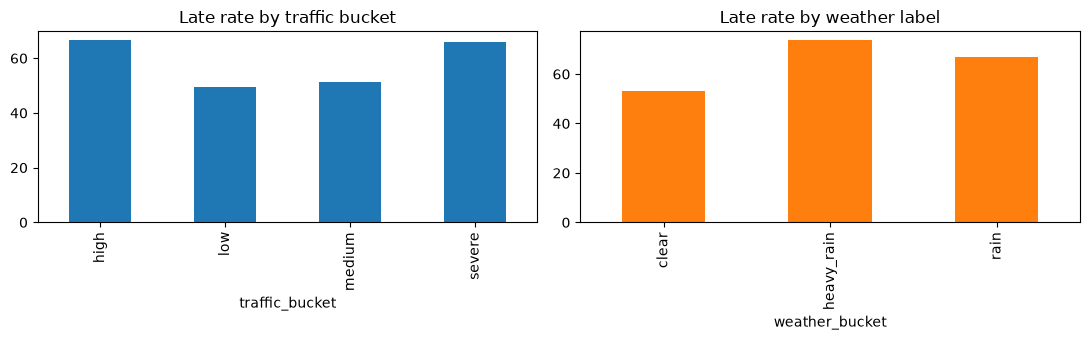

In [7]:
def summarise(df, by):
    g = df.groupby(by, observed=True)["delay_min"].agg(count="count", median="median", mean="mean").round(1)
    g["late_rate_%"] = (df.assign(l=df.delay_min > 0).groupby(by, observed=True)["l"].mean() * 100).round(1)
    return g
for by, frame in [("traffic_bucket", valid), ("weather_bucket", valid),
                  ("distance_band", valid.assign(distance_band=pd.cut(valid.distance_km_estimate, [0, 3, 6, 10, 20, 50], include_lowest=True))),
                  ("hour", valid.assign(hour=valid.created_at.dt.hour))]:
    display(summarise(frame, by))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
summarise(valid, "traffic_bucket")["late_rate_%"].plot(kind="bar", ax=ax[0], title="Late rate by traffic bucket")
summarise(valid, "weather_bucket")["late_rate_%"].plot(kind="bar", ax=ax[1], title="Late rate by weather label", color="tab:orange")
plt.tight_layout(); plt.savefig(OUT / "class5_traffic_weather.png", dpi=110); plt.show()

> ✅ **Answer**

**Hypothesis supported by the evidence:** lateness is associated with traffic and with the weather label.
- By traffic, the late rate rises from 49 % in low traffic to 66 % in severe traffic.
- By weather label, it rises from 53 % when clear to 74 % in heavy rain.
- Normalising the `HIGH` spelling first stops it from appearing as a fifth, misleading bucket.

**Alternative explanation that cannot be ruled out:** the evening peak raises traffic, kitchen load and driver scarcity at the same time. Distance shows no pattern.

**Beyond the class:** the pipeline checked the weather label against Open-Meteo's *observed* Bengaluru rainfall. The two agree about as often as chance (kappa ≈ 0). Orders labelled heavy rain saw no more rain than orders labelled clear, so the weather association is an association with a label, not with the sky.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [8]:
display(tickets.head())

print("Complaint categories:")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())

# Join syntax if useful:
# merged = tickets.merge(order_analysis, on="order_id", how="left")

# TODO: compare support evidence with delivery analysis

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs:
1


In [9]:
print("rows:", len(tickets), "| unique ids:", tickets.ticket_id.nunique(), "| exact duplicate rows:", tickets.duplicated().sum(), "| no order_id:", tickets.order_id.isna().sum())
t = tickets.drop_duplicates().assign(category_norm=lambda d: d.category.str.strip().str.lower().str.replace(r"[\s-]+", "_", regex=True))
tv = t.merge(valid[["order_id", "delay_min"]], on="order_id", how="left")      # LEFT: tickets are the base table
assert len(tv) == len(t), "join inflated the ticket count"
display(tv.groupby("category_norm").agg(tickets=("ticket_id", "size"), matched=("delay_min", "count"), median_delay=("delay_min", "median"),
                                          late_share_pct=("delay_min", lambda s: round(100 * (s > 0).mean(), 1))).round(1).sort_values("tickets", ascending=False))

rows: 202 | unique ids: 201 | exact duplicate rows: 1 | no order_id: 3


,tickets,matched,median_delay,late_share_pct
category_norm,,,,
late_delivery,39,38,14.8,84.6
restaurant_delay,37,37,10.5,75.7
eta_changed,37,35,7.7,75.7
ready_but_waiting,33,33,12.2,90.9
status_mismatch,29,28,12.7,89.7
driver_not_moving,25,25,10.4,68.0
eta_issue,1,1,5.4,100.0


> ✅ **Answer**

| | Customer view (tickets) | System view (orders) |
|---|---|---|
| Most common complaint | `late_delivery` (39 after normalising and removing the duplicate), then `eta_changed` and `restaurant_delay` | 56 % of all deliveries are late, so a ticket is the exception, not the rule |
| Are the complaints justified? | yes | ticketed `late_delivery` orders have a median delay of **14.8 min** and 85 % of them were late; 90 % for `ready_but_waiting` and `status_mismatch` |
| `ready_but_waiting` / `status_mismatch` | the restaurant says ready, the app says picking up | 90 % late, and the gap between restaurant and rider is real but **unmeasured** (no arrival event) |
| Hygiene | 1 duplicated ticket ID, 3 tickets without an order, 3 spelling variants | the support system is not the event log |

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [10]:
# [classroom cell, made robust] start the mock Dispatch API and wait until it is healthy (instead of a fixed sleep)
api_script = BASE / "api" / "mock_dispatch_api.py"
api_proc = subprocess.Popen([sys.executable, str(api_script)], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
for _ in range(60):
    try:
        if requests.get("http://127.0.0.1:8000/health", timeout=2).ok:
            break
    except requests.RequestException:
        time.sleep(0.25)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [11]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [12]:
RAW_SUBDIR = "raw_dispatch_student"

# [classroom skeleton completed] reliable paginated ingestion
# Requirements from the skeleton: fetch every page, retry HTTP 500 / 429, preserve successful raw
# responses, fail clearly on unrecoverable errors, verify the final record count.
API_URL = "http://127.0.0.1:8000/dispatch/orders"
RAW_DIR = OUT / RAW_SUBDIR                           # NOT inside source_systems/ - the client snapshot stays untouched
RAW_DIR.mkdir(parents=True, exist_ok=True)

def fetch_all_dispatch_orders(page_size=100, max_retries=4, timeout=10):
    records, seen, page, expected_total, log = [], set(), 1, None, []
    while True:
        for attempt in range(1, max_retries + 1):
            try:
                r = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=timeout)
            except (requests.Timeout, requests.ConnectionError) as exc:
                log.append((page, attempt, type(exc).__name__)); time.sleep(min(2 ** (attempt - 1), 4)); continue
            if r.status_code in (429, 500, 502, 503, 504):
                wait = float(r.json().get("retry_after_seconds", 0)) if r.status_code == 429 else min(2 ** (attempt - 1), 4)
                log.append((page, attempt, r.status_code)); time.sleep(wait); continue
            r.raise_for_status()                          # 4xx = configuration bug, never retried
            payload = r.json()
            break
        else:
            raise RuntimeError(f"page {page} failed after {max_retries} attempts: {log[-3:]}")
        if not isinstance(payload.get("data"), list):     # HTTP 200 is not proof: validate the body
            raise RuntimeError(f"page {page}: unexpected payload keys {list(payload)}")
        (RAW_DIR / f"dispatch_page_{page:03d}.json").write_text(json.dumps(payload, indent=1), encoding="utf-8")
        expected_total = payload.get("total_records", expected_total)
        for rec in payload["data"]:
            if rec["order_id"] in seen:
                raise RuntimeError(f"order {rec['order_id']} returned twice - pagination overlap")
            seen.add(rec["order_id"]); records.append(rec)
        if not payload.get("has_more"):
            break
        page += 1
    if expected_total is not None and len(records) != expected_total:
        raise RuntimeError(f"incomplete ingestion: got {len(records)}, server reports {expected_total}")
    return records, log

dispatch_records, retry_log = fetch_all_dispatch_orders()
dispatch_df = pd.DataFrame(dispatch_records)
print("pages saved:", len(list(RAW_DIR.glob("dispatch_page_*.json"))), "| retried:", retry_log)
print("records:", len(dispatch_df), "| unique orders:", dispatch_df["order_id"].nunique(), "| reassigned:", dispatch_df["reassigned_at"].notna().sum())
display(dispatch_df.head())

pages saved: 16 | retried: [(3, 1, 500), (5, 1, 429)]
records: 1600 | unique orders: 1600 | reassigned: 95


,assigned_at,current_delivery_eta,dispatch_status,driver_id,estimated_pickup_at,eta_model_version,order_id,original_driver_id,reassigned_at
0,2026-08-13T13:01:09.659644,2026-08-13T14:19:15.546424,completed,D103,2026-08-13T13:14:00,eta-v3.2,O00001,D103,NaN
1,2026-08-01T18:37:09.708219,2026-08-01T20:01:16.627988,completed,D083,2026-08-01T18:54:00,eta-v3.2,O00002,D083,NaN
2,2026-08-01T19:35:00.002443,2026-08-01T20:22:59.204700,completed,D039,2026-08-01T19:53:00,eta-v3.2,O00003,D039,NaN
3,2026-08-09T18:17:16.087835,2026-08-09T19:51:58.608301,cancelled,D038,2026-08-09T18:34:00,eta-v3.2,O00004,D038,NaN
4,2026-08-06T20:36:55.346822,2026-08-06T22:13:17.537116,completed,D047,2026-08-06T20:53:00,eta-v3.1,O00005,D047,NaN


# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

In [13]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# TODO: can you find an explicit driver_arrived_at_restaurant event?

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

In [14]:
ev = driver_events_df.assign(ts=pd.to_datetime(driver_events_df.timestamp, format="mixed"))
piv = ev[ev.type.isin(["assigned", "picked_up", "delivered"])].groupby(["order_id", "type"]).ts.min().unstack()
pings = ev[ev.type == "gps_ping"].merge(piv, left_on="order_id", right_index=True)
print("explicit arrival events:", (ev.type == "arrived_at_restaurant").sum())
print("pings before pickup:", (pings.ts <= pings.picked_up).sum(), "| after pickup:", (pings.ts > pings.picked_up).sum(),
      "| out-of-area pings (lat>13.5 or lon>78):", ((pings.lat > 13.5) | (pings.lon > 78)).sum())
print("orders with picked_up before assigned:", (piv.picked_up < piv.assigned).sum())
missing = oa[(oa.final_status == "delivered") & oa.actual_delivery_at.isna()].order_id
print("delivered orders missing actual time that DO have a driver 'delivered' event:", missing.isin(piv[piv.delivered.notna()].index).sum(), "of", len(missing))

explicit arrival events: 0
pings before pickup: 1632 | after pickup: 3739 | out-of-area pings (lat>13.5 or lon>78): 189
orders with picked_up before assigned: 14
delivered orders missing actual time that DO have a driver 'delivered' event: 37 of 37


> ✅ **Answer**

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | **Observed** | Dispatch `assigned_at`; driver app `assigned` | 14 orders are picked up *before* they are assigned |
| Driver at restaurant | **Not observed** | none | GPS pings do not converge on the restaurant (see the Class 5 Starter), so the event cannot be inferred |
| Picked up | **Observed** | `orders.pickup_at`; driver app | agree for 1527 orders |
| Delivered | **Observed** | `orders.actual_delivery_at`; driver app | 37 DB gaps, all recoverable from the driver event, pending the owner's decision |

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

> ✅ **Answer**

1. **Problem size.** 56.4 % of 1495 valid deliveries were late (56.3 % validated). The median late order was 8 minutes late and P90 is about 18 minutes.
2. **Evidence.** 99 % of the lateness minutes accrue **before pickup**. Dispatch's pickup estimate is short by a median 8 minutes. Traffic and hour of day are associated with lateness; distance is not. The weather label does not match observed weather.
3. **Trusted sources.** The orders table for the promise and delivery time, Dispatch for assignments, the driver app for movement, and tickets for customer perception only.
4. **Uncertainty.** 37 unknown outcomes, 9 chronology violations, no arrival event, a stale driver ID after reassignment, and no owner for the KPI definition.
5. **Instrumentation.** An arrival tap, a mandatory delivery timestamp, reassignment written back to the orders table, a cancellation timestamp, and an explanation of how `weather_bucket` is produced.
6. **Decision: no AI predictor yet.** Ship the pickup-overrun trigger now (96 % precision on the held-out week). A future model must beat it.

In [15]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
